In [2]:
import pandas as pd

In [3]:
df=pd.read_csv(r"C:\Users\Administrator\Desktop\Machine Learning Engineer\bank+marketing\bank-full.csv", sep=";")

In [4]:
df.rename(columns={'default':'credit_default','balance':'avg_annual_bal','housing':'housing_loan','loan':'personal_loan','contact':'contact_type','month':'contact_month','campaign':'curr_campaign','pdays': 'passed_days',
           'previous': 'prev_campaign','poutcome':'prev_outcome'},inplace=True)
df.head()

,age,job,marital,education,credit_default,avg_annual_bal,housing_loan,personal_loan,contact_type,day,contact_month,duration,curr_campaign,passed_days,prev_campaign,prev_outcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


In [5]:
df1=df

In [6]:
df1=pd.get_dummies(df, drop_first=True)

In [7]:
df1.corr()['y_yes'].sort_values(ascending=False)

y_yes                     1.000000
duration                  0.394521
prev_outcome_success      0.306788
contact_month_mar         0.129456
contact_month_oct         0.128531
contact_month_sep         0.123185
passed_days               0.103621
prev_campaign             0.093236
job_retired               0.079245
job_student               0.076897
contact_month_dec         0.075164
education_tertiary        0.066448
marital_single            0.063526
avg_annual_bal            0.052838
contact_month_feb         0.038417
job_management            0.032919
prev_outcome_other        0.031955
age                       0.025155
job_unemployed            0.020390
contact_type_telephone    0.014042
education_unknown         0.012053
job_self-employed         0.000855
job_unknown               0.000267
contact_month_aug        -0.008536
contact_month_jan        -0.008783
job_technician           -0.008970
contact_month_nov        -0.014937
job_housemaid            -0.015195
contact_month_jun   

In [22]:
from sklearn.tree import DecisionTreeClassifier

x= df2.drop('y_yes', axis=1)
y= df2['y_yes']

model= DecisionTreeClassifier()
model.fit(x,y)
importance=pd.Series(model.feature_importances_, index=x.columns)
importance.sort_values(ascending=False)

duration                  0.275281
avg_annual_bal            0.107216
day                       0.095546
age                       0.093770
prev_outcome_success      0.092005
passed_days               0.043287
curr_campaign             0.027799
housing_loan_yes          0.022167
contact_month_mar         0.015819
prev_campaign             0.013905
contact_month_jun         0.013341
contact_type_unknown      0.011565
education_tertiary        0.011445
contact_month_aug         0.010953
contact_month_oct         0.010532
marital_married           0.010521
job_technician            0.010308
education_secondary       0.009975
contact_month_may         0.009791
contact_month_jul         0.009690
job_management            0.009660
contact_month_jan         0.007363
marital_single            0.007084
contact_month_nov         0.006944
contact_month_feb         0.006806
job_blue-collar           0.006766
personal_loan_yes         0.006499
job_services              0.006127
contact_month_sep   

In [22]:
from sklearn.linear_model import Lasso

lasso = Lasso(alpha=0.01)
lasso.fit(x, y)

importance = pd.Series(lasso.coef_, index=x.columns)
importance.sort_values(ascending=False)

prev_outcome_success      0.148021
prev_campaign             0.003672
duration                  0.000485
passed_days               0.000235
age                       0.000169
avg_annual_bal            0.000004
prev_outcome_other       -0.000000
contact_month_sep         0.000000
contact_month_oct         0.000000
contact_month_nov        -0.000000
contact_month_may        -0.000000
education_unknown         0.000000
contact_month_jun         0.000000
contact_month_jul        -0.000000
contact_month_jan        -0.000000
contact_month_feb         0.000000
contact_month_dec         0.000000
contact_month_aug        -0.000000
contact_type_telephone    0.000000
personal_loan_yes        -0.000000
credit_default_yes       -0.000000
contact_month_mar         0.000000
education_tertiary        0.000000
education_secondary      -0.000000
job_student               0.000000
job_blue-collar          -0.000000
job_entrepreneur         -0.000000
job_housemaid            -0.000000
job_management      

In [10]:
from sklearn.feature_selection import RFE
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

scaler=StandardScaler()
x_scaled=scaler.fit_transform(x)

model = LogisticRegression(max_iter=500)
rfe = RFE(model, n_features_to_select=10)
rfe.fit(x_scaled, y)

selected_features = x.columns[rfe.support_]
print(selected_features)

Index(['duration', 'curr_campaign', 'housing_loan_yes', 'contact_type_unknown',
       'contact_month_aug', 'contact_month_jan', 'contact_month_jul',
       'contact_month_may', 'contact_month_nov', 'prev_outcome_success'],
      dtype='object')


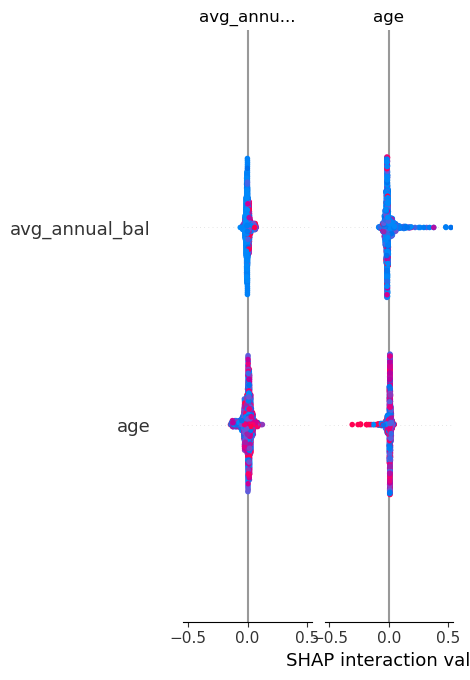

In [10]:
from sklearn.ensemble import RandomForestClassifier
import shap

model= RandomForestClassifier(random_state=42)

# Train on full data
model.fit(x, y)

# Sample for SHAP
X_sample = x.sample(1000, random_state=42)

# Convert to float if needed
X_sample = X_sample.astype(float)

# SHAP
explainer = shap.TreeExplainer(model)

shap_values = explainer.shap_values(X_sample)

shap.summary_plot(shap_values, X_sample)

In [24]:
import numpy as np
import pandas as pd

shap_importance = np.abs(shap_values[:,:,1]).mean(axis=0)

importance_df = pd.DataFrame({
    "Feature": x.columns,
    "SHAP Importance": shap_importance
}).sort_values(by="SHAP Importance", ascending=False)

print(importance_df)

                   Feature  SHAP Importance
3                 duration         0.084902
27    contact_type_unknown         0.023861
24        housing_loan_yes         0.020030
40    prev_outcome_success         0.017983
0                      age         0.014488
1           avg_annual_bal         0.012310
2                      day         0.011944
5              passed_days         0.011326
35       contact_month_may         0.009857
41    prev_outcome_unknown         0.009786
4            curr_campaign         0.009378
6            prev_campaign         0.008136
33       contact_month_jun         0.007351
32       contact_month_jul         0.006610
34       contact_month_mar         0.005768
18         marital_married         0.005630
28       contact_month_aug         0.005031
21      education_tertiary         0.004817
19          marital_single         0.004476
25       personal_loan_yes         0.003894
37       contact_month_oct         0.003790
30       contact_month_feb      

In [11]:
from sklearn.feature_selection import mutual_info_classif
import pandas as pd

mi_scores = mutual_info_classif(x, y)

mi_df = pd.DataFrame({
    "Feature": x.columns,
    "MI Score": mi_scores
}).sort_values(by="MI Score", ascending=False)

print(mi_df)

                   Feature  MI Score
3                 duration  0.072518
40    prev_outcome_success  0.030315
5              passed_days  0.025577
1           avg_annual_bal  0.021756
41    prev_outcome_unknown  0.019909
24        housing_loan_yes  0.016474
27    contact_type_unknown  0.015495
6            prev_campaign  0.011020
0                      age  0.010965
18         marital_married  0.010318
2                      day  0.008104
35       contact_month_may  0.007669
20     education_secondary  0.007033
38       contact_month_sep  0.005120
34       contact_month_mar  0.005022
37       contact_month_oct  0.004955
21      education_tertiary  0.004625
4            curr_campaign  0.004144
7          job_blue-collar  0.003470
25       personal_loan_yes  0.002635
10          job_management  0.002485
12       job_self-employed  0.002335
29       contact_month_dec  0.002332
19          marital_single  0.002100
14             job_student  0.001942
31       contact_month_jan  0.001503
2

In [26]:
from sklearn.inspection import permutation_importance
from sklearn.ensemble import RandomForestClassifier
import pandas as pd

# Train model
model = RandomForestClassifier(random_state=42)
model.fit(x, y)

# Permutation importance
perm = permutation_importance(
    model,
    x,
    y,
    n_repeats=10,
    random_state=42
)

perm_df = pd.DataFrame({
    "Feature": x.columns,
    "Importance": perm.importances_mean
}).sort_values(by="Importance", ascending=False)

print(perm_df)

                   Feature  Importance
3                 duration    0.103269
1           avg_annual_bal    0.028267
0                      age    0.024775
24        housing_loan_yes    0.024644
27    contact_type_unknown    0.021526
2                      day    0.020570
4            curr_campaign    0.016396
40    prev_outcome_success    0.014799
5              passed_days    0.012415
35       contact_month_may    0.011513
18         marital_married    0.010701
19          marital_single    0.008894
21      education_tertiary    0.007717
32       contact_month_jul    0.005698
28       contact_month_aug    0.005611
7          job_blue-collar    0.005437
20     education_secondary    0.005348
25       personal_loan_yes    0.005202
33       contact_month_jun    0.004713
34       contact_month_mar    0.004552
10          job_management    0.004289
6            prev_campaign    0.003824
15          job_technician    0.003661
37       contact_month_oct    0.003280
30       contact_month_fe

In [89]:
df1.dtypes

age                       int64
avg_annual_bal            int64
day                       int64
duration                  int64
curr_campaign             int64
passed_days               int64
prev_campaign             int64
job_blue-collar            bool
job_entrepreneur           bool
job_housemaid              bool
job_management             bool
job_retired                bool
job_self-employed          bool
job_services               bool
job_student                bool
job_technician             bool
job_unemployed             bool
job_unknown                bool
marital_married            bool
marital_single             bool
education_secondary        bool
education_tertiary         bool
education_unknown          bool
credit_default_yes         bool
housing_loan_yes           bool
personal_loan_yes          bool
contact_type_telephone     bool
contact_type_unknown       bool
contact_month_aug          bool
contact_month_dec          bool
contact_month_feb          bool
contact_

In [92]:
x1= df1.drop('y_yes', axis=1)
y1= df1['y_yes']

In [102]:
bool_cols= x1.select_dtypes(include='bool').columns
x1[bool_cols] = x1[bool_cols].astype(int)

In [103]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd

vif_df = pd.DataFrame()

vif_df["Feature"] = x1.columns

vif_df["VIF"] = [
    variance_inflation_factor(x1.values, i)
    for i in range(x1.shape[1])
]

vif_df.sort_values(by= 'VIF', ascending = False)

,Feature,VIF
41,prev_outcome_unknown,23.655041
0,age,19.405497
35,contact_month_may,6.254635
2,day,5.899113
18,marital_married,5.824164
20,education_secondary,4.767843
21,education_tertiary,4.433690
5,passed_days,4.128600
10,job_management,3.738496
33,contact_month_jun,3.615882


In [15]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler() #Minmax Scaler used to avoid negative values. chisquare test does not work on negative values.
X_scaled = scaler.fit_transform(x)
X_scaled = pd.DataFrame(X_scaled, columns=x.columns)

In [16]:
from sklearn.feature_selection import chi2
import pandas as pd

chi_scores, p_values = chi2(X_scaled, y)

chi_df = pd.DataFrame({
    "Feature": X_scaled.columns,
    "Chi2 Score": chi_scores,
    "P-value": p_values
}).sort_values(by="Chi2 Score", ascending=False)

chi_df

,Feature,Chi2 Score,P-value
40,prev_outcome_success,4113.000571,0.000000e+00
34,contact_month_mar,749.691937,4.681507e-165
37,contact_month_oct,734.708162,8.480926e-162
27,contact_type_unknown,733.354934,1.669907e-161
38,contact_month_sep,677.273004,2.617913e-149
24,housing_loan_yes,388.949715,1.401285e-86
3,duration,367.570299,6.327322e-82
35,contact_month_may,330.368818,7.988374e-74
11,job_retired,269.699331,1.319590e-60
14,job_student,261.792961,6.977480e-59


In [8]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler, RobustScaler
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

x= df[['age','avg_annual_bal','housing_loan','personal_loan','passed_days', 'prev_outcome', 'job', 'contact_month']]
y= df['y'].map({'no':0, 'yes':1})

x_train, x_test, y_train, y_test= train_test_split(x,y, test_size = 0.2, random_state=100, stratify=y)

onehot_cols = ['housing_loan', 'personal_loan','prev_outcome', 'job', 'contact_month']
# ordinal_cols = ['prev_outcome']
stanscale_cols = ['age','passed_days']
robscale_cols = ['avg_annual_bal']

preprocessor = ColumnTransformer(transformers=[
    ('onehot', OneHotEncoder(handle_unknown='ignore'), onehot_cols),
    # ('ordinal', OrdinalEncoder(), ordinal_cols),
    ('standard_scaler', StandardScaler(), stanscale_cols),
    ('robust_scaler', RobustScaler(), robscale_cols)])

pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LogisticRegression(class_weight='balanced'))])

pipeline.fit(x_train, y_train)
y_pred = pipeline.predict(x_test)


In [9]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
# print(classification_report(y_test, y_pred))

Accuracy: 0.7833683512108813
Precision: 0.2867960246095599
Recall: 0.5727788279773157
F1 Score: 0.38221381267738885
Confusion Matrix:
 [[6478 1507]
 [ 452  606]]


In [10]:
from sklearn.model_selection import cross_val_score
score= cross_val_score(pipeline, x_train, y_train, cv=5, scoring='f1')
print('cross_val_score:', score)
print('Mean:', score.mean())

cross_val_score: [0.36817473 0.37172979 0.37746257 0.3625498  0.38267717]
Mean: 0.3725188110283487


In [11]:
from sklearn.model_selection import GridSearchCV
param_grid = {
    'model__C': [0.001, 0.01, 0.1, 1, 10, 100],
    'model__solver': ['liblinear']
}

grid = GridSearchCV(pipeline, param_grid, cv=5, scoring='f1')
grid.fit(x_train,y_train)

print(grid.best_params_)
print(grid.best_score_)

{'model__C': 10, 'model__solver': 'liblinear'}
0.37285908325513134


In [21]:
grid.best_estimator_.score(x_test, y_test)

0.7834789339820856

In [12]:
y_prob= pipeline.predict_proba(x_test)[:,1]
y_pred= (y_prob >= 0.63).astype(int)

In [13]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.8741568063695676
Precision: 0.4576271186440678
Recall: 0.40831758034026466
F1 Score: 0.43156843156843155
Confusion Matrix:
 [[7473  512]
 [ 626  432]]
              precision    recall  f1-score   support

           0       0.92      0.94      0.93      7985
           1       0.46      0.41      0.43      1058

    accuracy                           0.87      9043
   macro avg       0.69      0.67      0.68      9043
weighted avg       0.87      0.87      0.87      9043



Best Threshold:  0.515
Best Threshold:  0.636
AUC Score: 0.7440971552284351


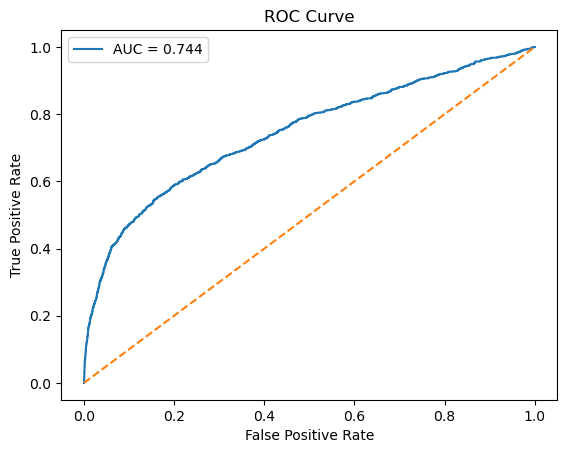

In [25]:
from sklearn.metrics import roc_curve, precision_recall_curve, roc_auc_score
import matplotlib.pyplot as plt
import numpy as np

# predicted probabilities
y_prob = pipeline.predict_proba(x_test)[:,1]

# ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
j_scores = tpr - fpr
best_idx = np.argmax(j_scores)
best_threshold_roc = thresholds[best_idx]

print(f"Best Threshold: {best_threshold_roc: .3f}")

# Precision_recall_curve
precision, recall, thresholds = precision_recall_curve(y_test, y_prob)
f1_scores = 2 * (precision * recall) / (precision + recall)
best_idx = np.argmax(f1_scores) 
best_threshold_prc = thresholds[best_idx]
print(f"Best Threshold: {best_threshold_prc: .3f}")

# AUC score
auc_score = roc_auc_score(y_test, y_prob)
print("AUC Score:", auc_score)

# Plot
plt.plot(fpr, tpr, label=f"AUC = {auc_score:.3f}")

# random classifier line
plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()

plt.show()

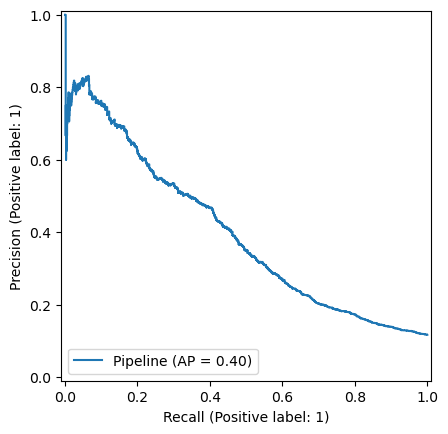

In [26]:
from sklearn.metrics import PrecisionRecallDisplay
PrecisionRecallDisplay.from_estimator(pipeline, x_test, y_test)

In [27]:
from sklearn.model_selection import TunedThresholdClassifierCV

tuned_model = TunedThresholdClassifierCV(pipeline, scoring="f1", cv=5)
tuned_model.fit(x_train, y_train)
print(f"The automatically found optimal threshold is: {tuned_model.best_threshold_:.4f}")

The automatically found optimal threshold is: 0.6324


In [27]:
from sklearn.tree import DecisionTreeClassifier

# Features and target
x= df[['age','avg_annual_bal','housing_loan','personal_loan','passed_days', 'prev_outcome', 'job', 'contact_month']]
y= df['y'].map({'no':0, 'yes':1})

# Train-test split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42, stratify=y)

onehot_cols = ['housing_loan', 'personal_loan','prev_outcome', 'job', 'contact_month']

preprocessor = ColumnTransformer(transformers=[
    ('onehot', OneHotEncoder(handle_unknown='ignore'), onehot_cols)],remainder= 'passthrough')

pipeline_tree = Pipeline([
    ('preprocessor', preprocessor),
    ('model', DecisionTreeClassifier(max_depth=5, class_weight='balanced'))
])

pipeline_tree.fit(x_train, y_train)
y_pred= pipeline_tree.predict(x_test)

In [43]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.8717239854030742
Precision: 0.44608879492600423
Recall: 0.3988657844990548
F1 Score: 0.42115768463073855
Confusion Matrix:
 [[7461  524]
 [ 636  422]]


In [44]:
score= cross_val_score(pipeline_tree, x_train, y_train, cv=5, scoring='f1')
print('cross_val_score:', score)
print('Mean:', score.mean())

cross_val_score: [0.4041514  0.40813884 0.30690537 0.32137084 0.31911163]
Mean: 0.35193561640280563


In [50]:
param_grid = {
    'model__max_depth': [5, 10, 15, 20],
    'model__criterion': ['gini', 'entropy'],
    'model__min_samples_split': [10, 20, 30, 40, 50, 60, 70, 80, 90, 100]
}

grid = GridSearchCV(
    pipeline_tree,
    param_grid,
    cv=5,
    scoring='f1'
)

grid.fit(x_train, y_train)

,estimator,Pipeline(step...ax_depth=5))])
,param_grid,"{'model__criterion': ['gini', 'entropy'], 'model__max_depth': [5, 10, ...], 'model__min_samples_split': [10, 20, ...]}"
,scoring,'f1'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('onehot', ...)]"


In [53]:
print(grid.best_params_)
print(grid.best_score_)

{'model__criterion': 'entropy', 'model__max_depth': 10, 'model__min_samples_split': 100}
0.42147206879730603


In [61]:
ytrain_pred = grid.best_estimator_.predict(x_test)
print('f1 score:', f1_score(y_test, ytrain_pred

f1 score: 0.4296238852268321


In [76]:
from xgboost import XGBClassifier

# Features and target
x= df[['age','avg_annual_bal','housing_loan','personal_loan','passed_days', 'prev_outcome', 'job', 'contact_month']]
y= df['y'].map({'no':0, 'yes':1})

# Split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42, stratify=y)

pos=(y_train == 1).sum()
neg=(y_train == 0).sum()

scale_pos_weight = neg / pos

onehot_cols = ['housing_loan', 'personal_loan','prev_outcome', 'job', 'contact_month']

preprocessor = ColumnTransformer(transformers=[
    ('onehot', OneHotEncoder(handle_unknown='ignore'), onehot_cols)],remainder= 'passthrough')

# Model
model = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=10,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='binary:logistic',
    eval_metric='logloss',
    scale_pos_weight=scale_pos_weight,
    random_state=42
)

pipeline_xgboost = Pipeline([
    ('preprocessor', preprocessor),
    ('model', model)
])


# Train
pipeline_xgboost.fit(x_train, y_train)

# Predict
y_pred = pipeline_xgboost.predict(x_test)

# Accuracy
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.841092557779498
Precision: 0.3672039243167484
Recall: 0.4952741020793951
F1 Score: 0.4217303822937626
Confusion Matrix:
 [[7082  903]
 [ 534  524]]


In [84]:
param_grid = {
    'model__n_estimators': [100, 200],
    'model__max_depth': [3, 5],
    'model__learning_rate': [0.05, 0.01],
    'model__subsample': [0.8, 1.0]
}

# Grid Search
grid = GridSearchCV(
    pipeline_xgboost,
    param_grid,
    cv=5,
    scoring='f1',
    verbose=1,
    n_jobs=-1
)

# Train
grid.fit(x_train, y_train)

# Best parameters
print("Best Parameters:", grid.best_params_)
print("Best CV Score:", grid.best_score_)

# Best model
ytrain_pred = grid.best_estimator_.predict(x_test)

# Performance check
print("Accuracy:", accuracy_score(y_test, ytrain_pred))
print("Precision:", precision_score(y_test, ytrain_pred))
print("Recall:", recall_score(y_test, ytrain_pred))
print("F1 Score:", f1_score(y_test, ytrain_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, ytrain_pred))

Fitting 5 folds for each of 16 candidates, totalling 80 fits
Best Parameters: {'model__learning_rate': 0.01, 'model__max_depth': 5, 'model__n_estimators': 200, 'model__subsample': 0.8}
Best CV Score: 0.4373544580209893
Accuracy: 0.8449629547716466
Precision: 0.3802228412256267
Recall: 0.5160680529300568
F1 Score: 0.43785084202085006
Confusion Matrix:
 [[7095  890]
 [ 512  546]]


In [ ]:
# Linear Regression- Part 2 of Project

In [15]:
df1= df

In [16]:
X= df1[['age','housing_loan','personal_loan','passed_days', 'prev_outcome', 'job', 'contact_month', 'avg_annual_bal']]
Y= df1['y'].map({'no':0, 'yes':1})

In [17]:
# Logistic regression pipeline

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler, RobustScaler
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

LX_train, LX_test, LY_train, LY_test = train_test_split(X, Y, test_size= 0.3, random_state=100, stratify=Y)

onehot_cols = ['housing_loan', 'personal_loan','prev_outcome', 'job', 'contact_month']
stanscale_cols = ['age','passed_days']
robscale_cols = ['avg_annual_bal']

preprocessor = ColumnTransformer(transformers=[
    ('onehot', OneHotEncoder(handle_unknown='ignore'), onehot_cols),
    # ('ordinal', OrdinalEncoder(), ordinal_cols),
    ('standard_scaler', StandardScaler(), stanscale_cols),
    ('robust_scaler', RobustScaler(), robscale_cols)])

pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LogisticRegression(class_weight='balanced'))])

pipeline.fit(LX_train, LY_train)


,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('onehot', ...), ('standard_scaler', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [18]:
# Logistic regression pipeline ran on training set using cross value prediction method
from sklearn.model_selection import cross_val_predict
train_prob= cross_val_predict(pipeline, LX_train, LY_train, method= 'predict_proba')[:,1]

In [19]:
# Target variable Y (Revenue) created for training set
train_rev= train_prob * LX_train['avg_annual_bal']
train_rev.head()

44481       0.000000
25167       0.000000
40209    3707.869016
30954      71.530710
26429     788.138493
Name: avg_annual_bal, dtype: float64

In [20]:
# Target variable Y(Revenue) created for test set
test_rev= pipeline.predict_proba(LX_test)[:,1] * LX_test['avg_annual_bal']
test_rev.head()

34601   -110.146670
17030     64.534540
27798    605.794738
41138    180.262199
29144     86.683404
Name: avg_annual_bal, dtype: float64

In [21]:
# Linear model fitting on training data

from sklearn.linear_model import LinearRegression

onehot_cols = ['housing_loan', 'personal_loan','prev_outcome', 'job', 'contact_month']
stanscale_cols = ['age','passed_days']

preprocessor = ColumnTransformer(transformers=[
    ('onehot', OneHotEncoder(handle_unknown='ignore'), onehot_cols),
    ('standard_scaler', StandardScaler(), stanscale_cols)])

Linear_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LinearRegression())])

Linear_pipeline.fit(LX_train, train_rev)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('onehot', ...), ('standard_scaler', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [22]:
# Linear model prediction on test data
y_pred = Linear_pipeline.predict(LX_test)

In [23]:
# Evaluation

from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

r2 = r2_score(test_rev, y_pred)
mae = mean_absolute_error(test_rev, y_pred)
rmse = np.sqrt(mean_squared_error(test_rev, y_pred))

print("R2 Score:", r2)
print("MAE:", mae)
print("RMSE:", rmse)

R2 Score: 0.05819464461539681
MAE: 766.4429465041992
RMSE: 1945.5148287480952


In [24]:
X= df1[['age','job','marital','education', 'credit_default','housing_loan','personal_loan','contact_type','contact_month','prev_outcome']]
Y= df1['avg_annual_bal']

In [25]:
# Linear model fitting on target variable (avg_annual_bal)

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline

LX_train, LX_test, LY_train, LY_test = train_test_split(X, Y, test_size= 0.3, random_state=100)

from sklearn.linear_model import LinearRegression

onehot_cols = ['job','marital','education','credit_default','housing_loan','personal_loan','contact_type','contact_month','prev_outcome']
stanscale_cols = ['age']

preprocessor = ColumnTransformer(transformers=[
    ('onehot', OneHotEncoder(handle_unknown='ignore'), onehot_cols),
    ('standard_scaler', StandardScaler(), stanscale_cols)])

Linear1_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LinearRegression())])

Linear1_pipeline.fit(LX_train, LY_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('onehot', ...), ('standard_scaler', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [26]:
LY_pred= Linear1_pipeline.predict(LX_test)

In [27]:
# Evaluation

from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

r2 = r2_score(LY_test, LY_pred)
mae = mean_absolute_error(LY_test, LY_pred)
rmse = np.sqrt(mean_squared_error(LY_test, LY_pred))

print("R2 Score:", r2)
print("MAE:", mae)
print("RMSE:", rmse)

R2 Score: 0.04623640707592147
MAE: 1459.7237907243245
RMSE: 2705.9830177932868


In [28]:
# Using Cross validation dataset

from sklearn.model_selection import cross_val_score
score= cross_val_score(Linear1_pipeline, LX_train, LY_train, cv=5, scoring='r2')
print('cross_val_score:', score)
print('Mean:', score.mean())

cross_val_score: [0.05371003 0.04373061 0.04854476 0.04565006 0.04208068]
Mean: 0.04674322981762906


In [88]:
# Implementing ridge (L2 regularization) to check for improvement if any:

from sklearn.linear_model import Ridge

Ridge_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', Ridge(alpha=1.0))
])

Ridge_pipeline.fit(LX_train, LY_train)

ridge_pred = Ridge_pipeline.predict(LX_test)

print("R2 Score:", r2_score(LY_test, ridge_pred))
print("MAE:", mean_absolute_error(LY_test, ridge_pred))
print("RMSE:", np.sqrt(mean_squared_error(LY_test, ridge_pred)))

R2 Score: 0.04624119932306325
MAE: 1459.7017026835706
RMSE: 2705.9762195910025


In [29]:
# Using RidgeCV to optimize alpha

from sklearn.linear_model import RidgeCV

RidgeCV_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RidgeCV(alphas=[0.01, 0.1, 1, 10, 100]))
])

RidgeCV_pipeline.fit(LX_train, LY_train)

ridgecv_pred = RidgeCV_pipeline.predict(LX_test)

print("Best Alpha:",
      RidgeCV_pipeline.named_steps['model'].alpha_)

print("R2 Score:",
      r2_score(LY_test, ridgecv_pred))

Best Alpha: 100.0
R2 Score: 0.04659042451205342


In [90]:
# Implementing Lasso (L1 regularization) to check for improvement if any:

from sklearn.linear_model import Lasso

Lasso_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', Lasso(alpha=1.0))
])

Lasso_pipeline.fit(LX_train, LY_train)

lasso_pred = Lasso_pipeline.predict(LX_test)

print("R2 Score:", r2_score(LY_test, lasso_pred))
print("MAE:", mean_absolute_error(LY_test, lasso_pred))
print("RMSE:", np.sqrt(mean_squared_error(LY_test, lasso_pred)))

R2 Score: 0.0468229073226859
MAE: 1458.3675699206758
RMSE: 2705.150891374249


In [91]:
# Using RidgeCV to optimize alpha

from sklearn.linear_model import LassoCV

LassoCV_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LassoCV(alphas=[0.01, 0.1, 1, 10, 100],
                      cv=5,
                      random_state=100))
])

LassoCV_pipeline.fit(LX_train, LY_train)

lassocv_pred = LassoCV_pipeline.predict(LX_test)

print("Best Alpha:",
      LassoCV_pipeline.named_steps['model'].alpha_)

print("R2 Score:",
      r2_score(LY_test, lassocv_pred))

Best Alpha: 1.0
R2 Score: 0.0468229073226859
